In [1]:
import arviz as az
import jax
import numpyro
import polars as pl
from jax import numpy as jnp
from numpyro import distributions as dist
from numpyro.infer import MCMC, NUTS 
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OrdinalEncoder
import numpy as np

from matplotlib import pyplot as plt

numpyro.set_host_device_count(4)

In [8]:
scores = pl.read_csv("scores.csv")
max_score = scores.group_by("Game").agg(pl.col("Total").max().alias("max_score"))

scores = (
    scores.join(max_score, on="Game")
    .with_columns(
        (pl.col("Total") == pl.col("max_score")).alias("winner"),
        pl.when(pl.col("Expansions").eq("EE"))
        .then(pl.lit("Europe"))
        .when(pl.col("Expansions").eq("AE"))
        .then(pl.lit("Asia"))
        .when(pl.col("Expansions").eq("EE,OE"))
        .then(pl.lit("Oceania"))
        .when(pl.col("Expansions").eq("EE,OE,AE"))
        .then(pl.lit("All"))
        .otherwise(pl.lit("Other"))
        .alias("Expansions")
    )
    .select(pl.exclude("max_score"))
    .with_columns(
        ((pl.col(col) / pl.col("Total")).alias(f"{col.lower().replace(" ", "_")}_pct")
        for col in ["Birds", "Bonus Cards", "Food on Cards", "Eggs", "Tucked Cards", "Nectar", "Duet Tokens"])
    )
)

scores.head()


Game,Expansions,Player,Birds,Bonus Cards,End of Round Goals,Eggs,Food on Cards,Tucked Cards,Nectar,Duet Tokens,Total,winner,birds_pct,bonus_cards_pct,food_on_cards_pct,eggs_pct,tucked_cards_pct,nectar_pct,duet_tokens_pct
i64,str,str,i64,i64,i64,i64,i64,i64,i64,i64,i64,bool,f64,f64,f64,f64,f64,f64,f64
1,"""Europe""","""Yizhou""",28,6,7,26,0,26,0,0,93,false,0.301075,0.064516,0.0,0.27957,0.27957,0.0,0.0
1,"""Europe""","""Sam""",30,7,12,13,0,41,0,0,103,true,0.291262,0.067961,0.0,0.126214,0.398058,0.0,0.0
1,"""Europe""","""Camille""",38,6,9,13,0,8,0,0,74,false,0.513514,0.081081,0.0,0.175676,0.108108,0.0,0.0
1,"""Europe""","""Matt""",32,7,7,25,1,19,0,0,91,false,0.351648,0.076923,0.010989,0.274725,0.208791,0.0,0.0
2,"""Europe""","""Camille""",34,6,20,22,5,7,0,0,94,false,0.361702,0.06383,0.053191,0.234043,0.074468,0.0,0.0


In [9]:
preprocessor = ColumnTransformer(
    [
        ("encoder", OrdinalEncoder(), ["Expansions", "Player"]),
        (
            "pass",
            "passthrough",
            [
                "birds_pct",
                "bonus_cards_pct",
                "food_on_cards_pct",
                "eggs_pct",
                "tucked_cards_pct",
                "nectar_pct",
                "duet_tokens_pct",
            ],
        ),
    ]
)

score_data = jnp.array(preprocessor.fit_transform(scores))

players = score_data[:, 1].astype(jnp.int16)
expansions = score_data[:, 0].astype(jnp.int16)
winners = score_data[:, -1].astype(jnp.int16)
score_points = score_data[:, 2:-1].astype(jnp.int16)

preprocessor.transformers_[0][1].categories_

[array(['All', 'Asia', 'Europe', 'Oceania'], dtype=object),
 array(['A', 'B', 'Camille', 'Dad', 'J', 'Jon', 'Joy', 'Matt', 'Mom',
        'Sam', 'T', 'Yizhou'], dtype=object)]

In [ ]:
def mvn_model(expansions, players, X=None):
    n_players = 12
    n_categories = 6
    n_expansions = 4

    total_points = numpyro.deterministic(
        "total_points", jnp.sum(point_dist, axis=1) + nectar_points
    )

In [37]:
# score_points[:5, 0:6]
score_points[:, 6]

Array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0, 12,  7, 12,  7,  7,  9,  7, 12,  9, 10,
       15,  4,  9, 12,  5, 13, 12,  9,  9, 12,  7, 10, 12,  9,  0,  0,  0,
        0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0],      dtype=int16)

In [38]:
kernel = NUTS(mvn_model)
mcmc = MCMC(kernel, num_warmup=1000, num_samples=1000, num_chains=4)

key = jax.random.key(481)

mcmc.run(
    key,
    expansions=expansions,
    players=players,
    X=score_points
)

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

  0%|          | 0/2000 [00:00<?, ?it/s]

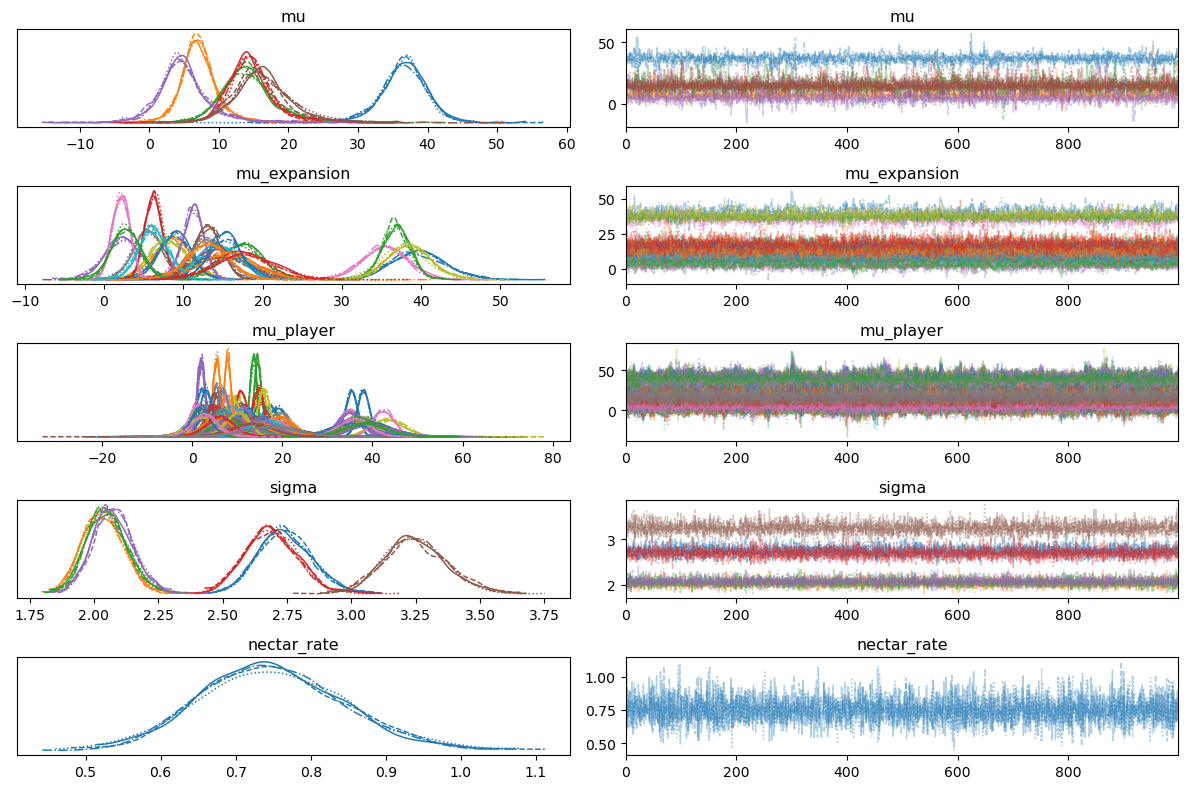

In [39]:
player_labels = preprocessor.named_transformers_["encoder"].categories_[1]
expansion_labels = preprocessor.named_transformers_["encoder"].categories_[0]
point_labels = ["birds", "bonus_cards", "eor", "eggs", "food_on_cards", "tucked_cards"]

trace = az.from_numpyro(
    mcmc,
    coords={
        "players": player_labels,
        "expansions": expansion_labels,
        "point_categories": point_labels,
    },
    dims={
        "mu_player": ["players", "expansions", "point_categories"],
        "mu_expansion": ["expansions", "point_categories"],
        "mu": ["point_categories"],
        "theta": ["point_categories"],
        "sigma": ["point_categories"],
    },
)

az.plot_trace(
    trace,
    figsize=(12, 8),
    var_names=["mu", "mu_expansion", "mu_player", "sigma", "nectar_rate"]
)
plt.tight_layout()

array([<Axes: title={'center': '90.0% HDI'}>], dtype=object)

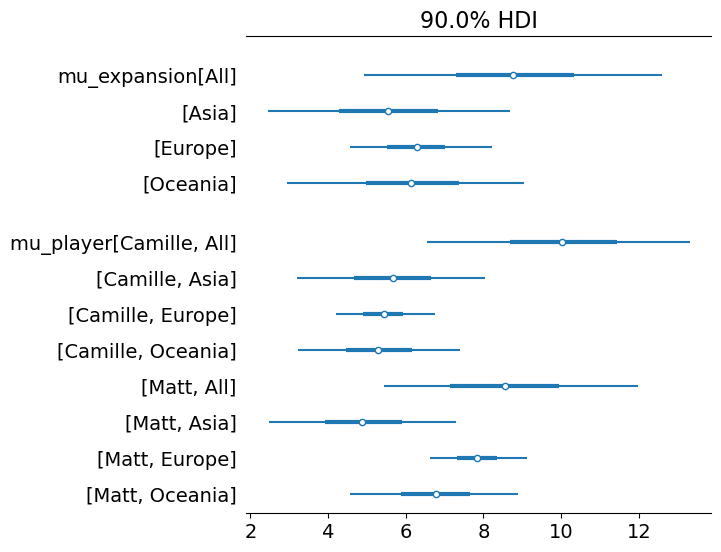

In [18]:
az.plot_forest(
    trace,
    var_names=["mu_expansion", "mu_player"],
    combined=True,
    coords={"players": ["Camille", "Matt"], "point_categories": ["bonus_cards"]},
    hdi_prob=0.90
)

In [ ]:
fn = numpyro.infer.Predictive(mvn_model, mcmc.get_samples(), return_sites=["total_points", "nectar_points"])

pred_X = pl.DataFrame(
    {
        "Expansions": ["Europe", "Europe", "Asia", "Asia", "Oceania", "Oceania", "All", "All"],
        "Player": ["Matt", "Camille", "Matt", "Camille", "Matt", "Camille", "Matt", "Camille"],
    }
)
input_data = jnp.array(preprocessor.transformers_[0][1].transform(pred_X)).astype(jnp.int16)

sim_points = fn(
    jax.random.PRNGKey(62628),
    expansions=input_data[:, 0],
    players=input_data[:, 1],
)



In [48]:
points = sim_points["total_points"]
for i, exp in zip(range(0, 8, 2), ["Europe", "Asia", "Oceania", "All"]):
    print(f"Prob Matt Win ({exp}): {(points[:, i] > points[:, i+1]).mean():0.4f}")

Prob Matt Win (Europe): 0.7878
Prob Matt Win (Asia): 0.6193
Prob Matt Win (Oceania): 0.7225
Prob Matt Win (All): 0.7550


In [50]:
sim_points["nectar_points"].shape

(4000,)